In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv ("50_Startups.csv")

In [3]:
dataset = pd.get_dummies (dataset,drop_first=True,dtype = int)

In [4]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [5]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [6]:
independent = dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]

In [7]:
dependent = dataset[['Profit']]

In [8]:
from sklearn.model_selection import train_test_split
x1,x2,y1,y2 = train_test_split(independent, dependent, test_size = 0.3, random_state=0)

In [9]:
from sklearn.preprocessing import StandardScaler
SC= StandardScaler()
x1= SC.fit_transform(x1)
x2 = SC.transform(x2)

SCy= StandardScaler()
y1= SCy.fit_transform(y1)
y2 = SCy.transform(y2)

In [10]:
from sklearn.tree import DecisionTreeRegressor

In [12]:
reg= DecisionTreeRegressor(criterion='absolute_error',splitter='best')
reg= reg.fit(x1,y1)

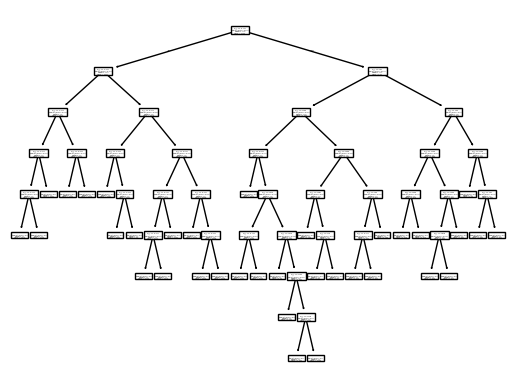

In [13]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(reg)
plt.show()

In [14]:
y_pred = reg.predict(x2)

In [15]:
from sklearn.metrics import r2_score

In [16]:
rscore= r2_score(y2,y_pred)

In [17]:
print (rscore)

0.9657251028552821


In [18]:
r= f"{rscore:.4f}"

In [19]:
print (r)

0.9657


In [28]:
import pickle
filename = 'final_DT_model.sav'

In [29]:
pickle.dump(reg,open(filename,'wb'))

In [30]:
preinput= SC.transform([[1300,12000,4000,0,1]])

C:\Users\ASUS\Anoconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [31]:
preinput

array([[-1.46755405, -4.33835385, -1.50744257, -0.5       ,  1.30088727]])

In [32]:
load_model=pickle.load(open(filename,'rb'))

In [33]:
result=load_model.predict(preinput)

In [34]:
result

array([-1.05315815])

In [35]:
preoutput=SCy.inverse_transform([result])
preoutput

array([[64926.08]])